In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/data-science-bowl-2018/stage1_test.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_sample_submission.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage2_sample_submission_final.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_train.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_train_labels.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_solution.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage2_test_final.zip


In [4]:
import zipfile
from pathlib import Path

zip_path = "/kaggle/input/competitions/data-science-bowl-2018/stage1_train.zip"
extract_to = Path("./train_dataset")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Unpacked directly to {extract_to}")

Unpacked directly to train_dataset


In [90]:
from pathlib import Path
import cv2
import numpy as np
from tqdm import tqdm

RAW_DATASET_DIR = Path('./train_dataset')
OUT_DIR = Path('./dataset_3class')

OUT_IMG_DIR = OUT_DIR / 'images'
OUT_MASK_DIR = OUT_DIR / 'masks'
OUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUT_MASK_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------
# boundary_thickness = 1 -> ~3-pixel total boundary width
# boundary_thickness = 2 -> ~5-pixel total boundary width (recommended)
BOUNDARY_THICKNESS = 1  


def pad_and_resize(
    img: np.ndarray,
    target_size: tuple = (256, 256),
    is_mask: bool = False,
    pad_value: int = 0,
) -> np.ndarray:
  h, w = img.shape[:2]
  scale = min(target_size[0] / w, target_size[1] / h)
  new_w, new_h = int(round(w * scale)), int(round(h * scale))

  interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_CUBIC
  resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

  pad_top = (target_size[1] - new_h) // 2
  pad_bottom = target_size[1] - new_h - pad_top
  pad_left = (target_size[0] - new_w) // 2
  pad_right = target_size[0] - new_w - pad_left

  if is_mask:
    # Always pad masks explicitly with 0 (Background)
    return cv2.copyMakeBorder(
        resized,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        cv2.BORDER_CONSTANT,
        value=pad_value,
    )
  else:
    # Pad images with reflection to prevent sharp black bar edge artifacts
    return cv2.copyMakeBorder(
        resized,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        cv2.BORDER_REFLECT,
    )


sample_folders = [f for f in RAW_DATASET_DIR.iterdir() if f.is_dir()]

print(f'Generating visible 3-class masks (Boundary Thickness: {BOUNDARY_THICKNESS})...')

# Dilation kernel for widening the boundary contours
kernel_size = 2 * BOUNDARY_THICKNESS + 1
dilation_kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE, (kernel_size, kernel_size)
)
erosion_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

for sample in tqdm(sample_folders):
  sample_id = sample.name

  # Save input image
  img_files = list((sample / 'images').glob('*.png'))
  if not img_files:
    continue
  img = cv2.imread(str(img_files[0]))
  cv2.imwrite(
      str(OUT_IMG_DIR / f'{sample_id}.png'),
      pad_and_resize(img, (256, 256), False),
  )

  # Process instance masks
  mask_files = list((sample / 'masks').glob('*.png'))
  interior_canvas = np.zeros((256, 256), dtype=bool)
  boundary_canvas = np.zeros((256, 256), dtype=bool)

  for m_file in mask_files:
    m = cv2.imread(str(m_file), cv2.IMREAD_GRAYSCALE)
    if m is None:
      continue
    m_padded = pad_and_resize(m, (256, 256), True) > 0
    if not m_padded.any():
      continue

    interior_canvas[m_padded] = True

    if np.sum(m_padded) > 20:
      # 1. Extract 1-pixel raw edge contour
      eroded = cv2.erode(
          m_padded.astype(np.uint8), erosion_kernel, iterations=1
      )
      raw_edge = (m_padded.astype(np.uint8) - eroded) > 0

      # 2. Dilate the edge to create a THICK boundary zone (~5px width)
      thick_edge = (
          cv2.dilate(raw_edge.astype(np.uint8), dilation_kernel, iterations=1)
          > 0
      )

      boundary_canvas[thick_edge] = True

  # Construct target mask using VISIBLE grayscale values:
  # 0 = Background, 100 = Interior, 200 = Boundary
  visible_target_mask = np.zeros((256, 256), dtype=np.uint8)
  
  # Set interiors first, then overwrite boundaries on top
  visible_target_mask[interior_canvas] = 100
  visible_target_mask[boundary_canvas] = 200

  # Save target PNG
  cv2.imwrite(str(OUT_MASK_DIR / f'{sample_id}.png'), visible_target_mask)

print('Done! Generated dataset with thick boundaries in ./dataset_3class/')

Generating visible 3-class masks (Boundary Thickness: 1)...


100%|██████████| 670/670 [00:32<00:00, 20.34it/s]

Done! Generated dataset with thick boundaries in ./dataset_3class/


In [50]:
""" Parts of the U-Net model """

import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        # if you have padding issues, see
        # https://github.com/HaiyongJiang/U-Net-Pytorch-Unstructured-Buggy/commit/0e854509c2cea854e247a9c615f175f76fbb2e3a
        # https://github.com/xiaopeng-liao/Pytorch-UNet/commit/8ebac70e633bac59fc22bb5195e513d5832fb3bd
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [51]:
""" Full assembly of the parts to form the complete network """



class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = (DoubleConv(n_channels, 64))
        self.down1 = (Down(64, 128))
        self.down2 = (Down(128, 256))
        self.down3 = (Down(256, 512))
        factor = 2 if bilinear else 1
        self.down4 = (Down(512, 1024 // factor))
        self.up1 = (Up(1024, 512 // factor, bilinear))
        self.up2 = (Up(512, 256 // factor, bilinear))
        self.up3 = (Up(256, 128 // factor, bilinear))
        self.up4 = (Up(128, 64, bilinear))
        self.outc = (OutConv(64, n_classes))

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def use_checkpointing(self):
        self.inc = torch.utils.checkpoint(self.inc)
        self.down1 = torch.utils.checkpoint(self.down1)
        self.down2 = torch.utils.checkpoint(self.down2)
        self.down3 = torch.utils.checkpoint(self.down3)
        self.down4 = torch.utils.checkpoint(self.down4)
        self.up1 = torch.utils.checkpoint(self.up1)
        self.up2 = torch.utils.checkpoint(self.up2)
        self.up3 = torch.utils.checkpoint(self.up3)
        self.up4 = torch.utils.checkpoint(self.up4)
        self.outc = torch.utils.checkpoint(self.outc)

In [122]:
import logging
from os import listdir
from os.path import splitext
from pathlib import Path
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset


class NucleiDataset(Dataset):

  def __init__(self, img_dir, mask_dir=None, transform=None):
    self.img_dir = Path(img_dir)
    self.mask_dir = Path(mask_dir) if mask_dir else None
    self.transform = transform

    # Fetch all test image files
    self.img_files = sorted(
        [
            f
            for f in self.img_dir.iterdir()
            if f.suffix.lower() in ['.png', '.jpg', '.jpeg', '.tif', '.tiff']
        ]
    )

  def __len__(self):
    return len(self.img_files)

  def __getitem__(self, idx):
    img_path = self.img_files[idx]
    img_id = img_path.stem

    # Read image using OpenCV
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert image to [C, H, W] float tensor normalized to [0, 1]
    image_tensor = torch.from_numpy(image.transpose((2, 0, 1))).float() / 255.0

    sample = {'image': image_tensor, 'image_id': img_id}

    # Load ground truth mask if directory is provided
    if self.mask_dir and self.mask_dir.exists():
      mask_path = self.mask_dir / f'{img_id}{img_path.suffix}'
      if not mask_path.exists():
        candidates = list(self.mask_dir.glob(f'{img_id}.*'))
        if candidates:
          mask_path = candidates[0]

      if mask_path.exists():
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        sample['mask'] = torch.from_numpy(mask).long()

    return sample

In [9]:
from pathlib import Path
import cv2
import numpy as np


def pad_and_resize(
    img: np.ndarray,
    target_size: tuple = (256, 256),
    is_mask: bool = False,
    pad_value: int = 0,
) -> np.ndarray:
  """Resizes image keeping aspect ratio intact and pads remaining areas."""
  h, w = img.shape[:2]
  target_w, target_h = target_size

  # Compute uniform scaling factor
  scale = min(target_w / w, target_h / h)
  new_w, new_h = int(round(w * scale)), int(round(h * scale))

  # Use NEAREST for masks to preserve class IDs, CUBIC for standard images
  interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_CUBIC
  resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

  # Calculate padding bounds (letterboxing)
  pad_top = (target_h - new_h) // 2
  pad_bottom = target_h - new_h - pad_top
  pad_left = (target_w - new_w) // 2
  pad_right = target_w - new_w - pad_left

  # Apply border padding
  if is_mask and resized.ndim == 2:
    padded = cv2.copyMakeBorder(
        resized,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        cv2.BORDER_CONSTANT,
        value=pad_value,
    )
  else:
    padded = cv2.copyMakeBorder(
        resized,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        cv2.BORDER_CONSTANT,
        value=[pad_value] * (img.shape[2] if img.ndim == 3 else 1),
    )

  return padded


# Directories Setup
RAW_IMG_DIR = Path('/kaggle/working/processed_dataset/images')
RAW_MASK_DIR = Path('/kaggle/working/processed_dataset/masks')

OUT_IMG_DIR = Path('./processed_256/images/')
OUT_MASK_DIR = Path('./processed_256/masks/')

OUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUT_MASK_DIR.mkdir(parents=True, exist_ok=True)

# Run transformation across dataset
for img_path in RAW_IMG_DIR.glob('*.png'):
  sample_id = img_path.stem
  mask_path = RAW_MASK_DIR / f'{sample_id}.png'

  # Process Image
  img = cv2.imread(str(img_path))
  img_proc = pad_and_resize(img, target_size=(256, 256), is_mask=False)
  cv2.imwrite(str(OUT_IMG_DIR / f'{sample_id}.png'), img_proc)

  # Process Mask
  if mask_path.exists():
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask_proc = pad_and_resize(mask, target_size=(256, 256), is_mask=True)
    cv2.imwrite(str(OUT_MASK_DIR / f'{sample_id}.png'), mask_proc)

print('All 670 images and masks resized to 256x256 without info loss!')

All 670 images and masks resized to 256x256 without info loss!


In [107]:
import numpy as np
import torch
import torch.nn.functional as F


def iou_single_object(pred_mask, gt_mask):
  """Computes IoU between a single predicted instance mask and a ground truth mask."""
  intersection = np.logical_and(pred_mask, gt_mask).sum()
  union = np.logical_or(pred_mask, gt_mask).sum()
  if union == 0:
    return 0.0
  return intersection / union


def compute_map_single_image(
    pred_instances, gt_instances, iou_thresholds=np.arange(0.5, 1.0, 0.05)
):
  """Computes Average Precision for a single image across IoU thresholds [0.5 to 0.95]."""
  pred_ids = [i for i in np.unique(pred_instances) if i > 0]
  gt_ids = [i for i in np.unique(gt_instances) if i > 0]

  if len(gt_ids) == 0 and len(pred_ids) == 0:
    return 1.0
  if len(gt_ids) == 0 or len(pred_ids) == 0:
    return 0.0

  iou_matrix = np.zeros((len(pred_ids), len(gt_ids)), dtype=np.float32)
  for i, p_id in enumerate(pred_ids):
    p_mask = pred_instances == p_id
    for j, g_id in enumerate(gt_ids):
      g_mask = gt_instances == g_id
      iou_matrix[i, j] = iou_single_object(p_mask, g_mask)

  precision_per_threshold = []

  for t in iou_thresholds:
    matched_gt = set()
    tp = 0
    fp = 0

    matches = np.argwhere(iou_matrix > t)
    if len(matches) > 0:
      scores = iou_matrix[matches[:, 0], matches[:, 1]]
      sorted_indices = np.argsort(-scores)

      matched_pred = set()
      for idx in sorted_indices:
        p_idx, g_idx = matches[idx]
        if p_idx not in matched_pred and g_idx not in matched_gt:
          tp += 1
          matched_pred.add(p_idx)
          matched_gt.add(g_idx)

      fp = len(pred_ids) - len(matched_pred)
    else:
      fp = len(pred_ids)

    fn = len(gt_ids) - len(matched_gt)
    denominator = tp + fp + fn
    precision = tp / denominator if denominator > 0 else 0.0
    precision_per_threshold.append(precision)

  return np.mean(precision_per_threshold)


def evaluate(net, dataloader, device, amp=True):
  """Validation function returning the official competition mAP score."""
  net.eval()
  map_scores = []

  with torch.no_grad():
    for batch in dataloader:
      images = batch['image'].to(device=device, dtype=torch.float32)
      true_masks = batch['mask'].cpu().numpy()  # Ground truth instance masks

      with torch.amp.autocast(
          device_type=device.type if device.type != 'mps' else 'cpu',
          enabled=amp,
      ):
        logits = net(images)
        probs = F.softmax(logits, dim=1).cpu().numpy()

      # Run post-processing for each image in the validation batch
      for i in range(images.shape[0]):
        # Extract predictions for image i
        prob_i = probs[i]
        gt_i = true_masks[i]

        # Process through concavity & bridge-pinching watershed
        pred_instances, num_found = pinch_off_and_separate_concavity(
    binary_mask=((prob_i[1] - 2.0 * prob_i[2]) > 0.40).astype(np.uint8),
    min_distance=4,
)

        image_map = compute_map_single_image(pred_instances, gt_i)
        map_scores.append(image_map)

  net.train()
  return np.mean(map_scores)

In [108]:
import torch
import torch.nn.functional as F
from torch import Tensor


def dice_coeff(
    input: Tensor,
    target: Tensor,
    reduce_batch_first: bool = False,
    epsilon: float = 1e-6,
):
  """Computes Dice coefficient between prediction and target tensors of matching dimensions."""
  assert (
      input.size() == target.size()
  ), f'Input shape {input.size()} must match Target shape {target.size()}'

  # Spatial dimensions for summation: (H, W) if 3D tensor [B, H, W], or (C, H, W) if batch-reduced
  sum_dim = (-1, -2) if input.dim() == 3 or not reduce_batch_first else (-1, -2, -3)

  intersection = 2 * (input * target).sum(dim=sum_dim)
  union = input.sum(dim=sum_dim) + target.sum(dim=sum_dim)

  # Prevent zero division
  union = torch.where(union == 0, intersection, union)

  dice = (intersection + epsilon) / (union + epsilon)
  return dice.mean()


def multiclass_dice_coeff(
    input: Tensor,
    target: Tensor,
    reduce_batch_first: bool = False,
    epsilon: float = 1e-6,
):
  """Computes mean Dice score across channels in 4D tensors [B, C, H, W]."""
  total_dice = 0.0
  num_channels = input.shape[1]

  for c in range(num_channels):
    total_dice += dice_coeff(
        input[:, c], target[:, c], reduce_batch_first, epsilon
    )

  return total_dice / num_channels


def dice_loss(input: Tensor, target: Tensor, multiclass: bool = True):
  """Computes multiclass Dice Loss targeting foreground classes (Interior & Boundary).

  input: Logits from UNet [B, 3, H, W] target: Class indices [B, H, W] containing
  values {0, 1, 2} or visible mask values {0, 100, 200}
  """
  if multiclass:
    # 1. Map target mask values [0, 100, 200] -> [0, 1, 2] if target wasn't remapped in Dataset
    if target.max() > 2:
      target_mapped = torch.zeros_like(target, dtype=torch.long)
      target_mapped[target == 100] = 1
      target_mapped[target == 200] = 2
    else:
      target_mapped = target.long()

    # 2. Compute Softmax probabilities: [B, 3, H, W]
    probs = F.softmax(input, dim=1)

    # 3. One-hot encode mapped targets: [B, H, W] -> [B, 3, H, W]
    num_classes = input.shape[1]
    target_one_hot = (
        F.one_hot(target_mapped, num_classes=num_classes)
        .permute(0, 3, 1, 2)
        .float()
    )

    # 4. Evaluate Dice Loss strictly on Foreground Channels (1: Interior, 2: Boundary)
    probs_fg = probs[:, 1:]
    target_fg = target_one_hot[:, 1:]

    return 1.0 - multiclass_dice_coeff(
        probs_fg, target_fg, reduce_batch_first=True
    )
  else:
    probs = (
        torch.sigmoid(input).squeeze(1)
        if input.dim() == 4
        else torch.sigmoid(input)
    )
    return 1.0 - dice_coeff(probs, target.float(), reduce_batch_first=True)

In [ ]:
import logging
import os
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, random_split
from tqdm.notebook import tqdm
import wandb

# ----------------------------------------------------------------------
# 1. Configuration & Hyperparameters
# ----------------------------------------------------------------------
EPOCHS = 40
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
VAL_PERCENT = 0.15
AMP = True
CLASSES = 3
BOUNDARY_WEIGHT = 4.0  # Reduced for widened (~5px) boundary targets
LOAD_MODEL_PATH = './checkpoints/checkpoint_epoch20.pth'
BILINEAR = False

DIR_IMG = Path('./dataset_3class/images')
DIR_MASK = Path('./dataset_3class/masks')
DIR_CHECKPOINT = Path('./checkpoints/')


# ----------------------------------------------------------------------
# 2. Training Function
# ----------------------------------------------------------------------
def train_model(
    model,
    device,
    dataset,
    epochs: int = 40,
    batch_size: int = 8,
    learning_rate: float = 1e-4,
    val_percent: float = 0.15,
    save_checkpoint: bool = True,
    amp: bool = True,
    weight_decay: float = 1e-4,
    gradient_clipping: float = 1.0,
    boundary_weight: float = 4.0,
):
  n_val = int(len(dataset) * val_percent)
  n_train = len(dataset) - n_val
  train_set, val_set = random_split(
      dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42)
  )

  loader_args = dict(
      batch_size=batch_size,
      num_workers=min(os.cpu_count() or 2, 4),
      pin_memory=True,
  )
  train_loader = DataLoader(train_set, shuffle=True, **loader_args)
  val_loader = DataLoader(val_set, shuffle=False, drop_last=False, **loader_args)

  experiment = wandb.init(project='U-Net-3Class-Nuclei', mode='disabled')

  logging.info(f"""Starting 3-Class Training:
        Epochs:          {epochs}
        Batch size:      {batch_size}
        Learning rate:   {learning_rate}
        Training size:   {n_train}
        Validation size: {n_val}
        Classes:         {model.n_classes}
        Boundary Weight: {boundary_weight}x
        Device:          {device.type}
        Mixed Precision: {amp}
    """)

  optimizer = optim.AdamW(
      model.parameters(), lr=learning_rate, weight_decay=weight_decay
  )
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(
      optimizer, mode='max', patience=4
  )
  scaler = torch.amp.GradScaler('cuda', enabled=amp and device.type == 'cuda')

  # Class weights: [Background=1.0, Interior=1.5, Boundary=4.0]
  class_weights = torch.tensor([1.0, 1.5, boundary_weight]).to(device)
  criterion = nn.CrossEntropyLoss(weight=class_weights)

  best_map = 0.0

  for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0

    with tqdm(
        total=len(train_loader), desc=f'Epoch {epoch}/{epochs}', unit='batch'
    ) as pbar:
      for batch in train_loader:
        images, true_masks = batch['image'], batch['mask']

        images = images.to(
            device=device,
            dtype=torch.float32,
            memory_format=torch.channels_last,
        )
        true_masks = true_masks.to(device=device, dtype=torch.long)

        # Ensure target values are mapped to [0, 1, 2]
        if true_masks.max() > 2:
          mapped_masks = torch.zeros_like(true_masks)
          mapped_masks[true_masks == 100] = 1
          mapped_masks[true_masks == 200] = 2
          true_masks = mapped_masks

        with torch.amp.autocast(
            device_type=device.type if device.type != 'mps' else 'cpu',
            enabled=amp,
        ):
          masks_pred = model(images)
          loss = criterion(masks_pred, true_masks) + dice_loss(
              masks_pred, true_masks, multiclass=True
          )

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), gradient_clipping
        )
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.update(1)
        pbar.set_postfix(**{'loss': loss.item()})

    avg_train_loss = epoch_loss / len(train_loader)

    # ------------------------------------------------------------------
    # End-of-Epoch Validation & Boundary Diagnostic Check
    # ------------------------------------------------------------------
    model.eval()
    max_boundary_prob = 0.0
    with torch.no_grad():
      for val_batch in val_loader:
        val_imgs = val_batch['image'].to(device=device, dtype=torch.float32)
        val_logits = model(val_imgs)
        val_probs = F.softmax(val_logits, dim=1)
        max_b = val_probs[:, 2, :, :].max().item()
        if max_b > max_boundary_prob:
          max_boundary_prob = max_b

    # Evaluate Competition Metric (mAP)
    val_map_score = evaluate(model, val_loader, device, amp)
    scheduler.step(val_map_score)

    logging.info(
        f'Epoch {epoch:02d}/{epochs:02d} | Train Loss: {avg_train_loss:.4f} | '
        f'Val mAP: {val_map_score:.4f} | Max Boundary Prob:'
        f' {max_boundary_prob:.4f}'
    )

    # Save Checkpoint if mAP improves or at regular intervals
    if save_checkpoint and (val_map_score > best_map or epoch % 5 == 0):
      best_map = max(val_map_score, best_map)
      DIR_CHECKPOINT.mkdir(parents=True, exist_ok=True)
      state_dict = model.state_dict()
      state_dict['mask_values'] = [0, 1, 2]
      torch.save(
          state_dict, str(DIR_CHECKPOINT / f'checkpoint_epoch{epoch}.pth')
      )
      logging.info(
          f'Saved checkpoint for Epoch {epoch} (Best mAP: {best_map:.4f})'
      )


# ----------------------------------------------------------------------
# 3. Execution Entry Point
# ----------------------------------------------------------------------
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f'Using device: {device}')

dataset = NucleiDataset(DIR_IMG, DIR_MASK)

model = UNet(n_channels=3, n_classes=CLASSES, bilinear=BILINEAR)
model = model.to(memory_format=torch.channels_last)

if LOAD_MODEL_PATH:
  state_dict = torch.load(LOAD_MODEL_PATH, map_location=device)
  if 'mask_values' in state_dict:
    del state_dict['mask_values']
  model.load_state_dict(state_dict)
  logging.info(f'Loaded weights from {LOAD_MODEL_PATH}')

model.to(device=device)

try:
  train_model(
      model=model,
      device=device,
      dataset=dataset,
      epochs=EPOCHS,
      batch_size=BATCH_SIZE,
      learning_rate=LEARNING_RATE,
      val_percent=VAL_PERCENT,
      amp=AMP,
      boundary_weight=BOUNDARY_WEIGHT,
  )
except torch.cuda.OutOfMemoryError:
  logging.error('OutOfMemoryError encountered! Enabling gradient checkpointing...')
  torch.cuda.empty_cache()
  if hasattr(model, 'use_checkpointing'):
    model.use_checkpointing(enabled=True)
  train_model(
      model=model,
      device=device,
      dataset=dataset,
      epochs=EPOCHS,
      batch_size=BATCH_SIZE,
      learning_rate=LEARNING_RATE,
      val_percent=VAL_PERCENT,
      amp=AMP,
      boundary_weight=BOUNDARY_WEIGHT,
  )

import zipfile
from pathlib import Path

zip_path = "/kaggle/input/competitions/data-science-bowl-2018/stage1_test.zip"
extract_to = Path("./test_dataset")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Unpacked directly to {extract_to}")

In [94]:
import cv2
import numpy as np
from pathlib import Path

# Paths (Adjust to your dataset directory)
DATASET_DIR = Path("/kaggle/working/test_dataset")  # Directory containing sample folders
OUTPUT_DIR = Path("./test_dataset")

IMAGES_OUT = OUTPUT_DIR / "images"
MASKS_OUT = OUTPUT_DIR / "masks"

IMAGES_OUT.mkdir(parents=True, exist_ok=True)
MASKS_OUT.mkdir(parents=True, exist_ok=True)

# Loop through each sample folder
sample_folders = [f for f in DATASET_DIR.iterdir() if f.is_dir()]

for sample in sample_folders:
    sample_id = sample.name
    
    # 1. Copy/Move original image
    img_files = list((sample / "images").glob("*.png"))
    if img_files:
        img = cv2.imread(str(img_files[0]))
        cv2.imwrite(str(IMAGES_OUT / f"{sample_id}.png"), img)
    
    # 2. Find and combine all individual mask images
    mask_files = list((sample / "masks").glob("*.png"))
    if mask_files:
        # Read the first mask to get dimensions (Height, Width)
        first_mask = cv2.imread(str(mask_files[0]), cv2.IMREAD_GRAYSCALE)
        combined_mask = np.zeros_like(first_mask, dtype=np.uint8)
        
        # Combine all masks using bitwise OR / pixel-wise max
        for m_file in mask_files:
            m = cv2.imread(str(m_file), cv2.IMREAD_GRAYSCALE)
            combined_mask = np.maximum(combined_mask, m)
            
        # Save merged mask
        cv2.imwrite(str(MASKS_OUT / f"{sample_id}.png"), combined_mask)

print(f"Done! Merged {len(sample_folders)} sample masks into: {OUTPUT_DIR.resolve()}")

Done! Merged 67 sample masks into: /kaggle/working/test_dataset


In [95]:
RAW_IMG_DIR = Path('/kaggle/working/test_dataset/images')
RAW_MASK_DIR = Path('/kaggle/working/test_dataset/masks')

OUT_IMG_DIR = Path('./test_256/images/')
OUT_MASK_DIR = Path('./test_256/masks/')

OUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUT_MASK_DIR.mkdir(parents=True, exist_ok=True)

# Run transformation across dataset
for img_path in RAW_IMG_DIR.glob('*.png'):
  sample_id = img_path.stem
  mask_path = RAW_MASK_DIR / f'{sample_id}.png'

  # Process Image
  img = cv2.imread(str(img_path))
  img_proc = pad_and_resize(img, target_size=(256, 256), is_mask=False)
  cv2.imwrite(str(OUT_IMG_DIR / f'{sample_id}.png'), img_proc)

  # Process Mask
  if mask_path.exists():
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask_proc = pad_and_resize(mask, target_size=(256, 256), is_mask=True)
    cv2.imwrite(str(OUT_MASK_DIR / f'{sample_id}.png'), mask_proc)

print('All 670 images and masks resized to 256x256 without info loss!')

All 670 images and masks resized to 256x256 without info loss!


In [112]:
import torch

# 1. Point to the specific saved checkpoint file
CHECKPOINT_PATH = './checkpoints/checkpoint_epoch40.pth'  # Use your latest epoch

# 2. Load state dict onto your device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)

# Clean metadata keys if present
if 'mask_values' in state_dict:
  del state_dict['mask_values']

# 3. Load into model architecture
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print(f'Successfully loaded weights from {CHECKPOINT_PATH}!')

Successfully loaded weights from ./checkpoints/checkpoint_epoch40.pth!


Processing: /kaggle/working/test_256/images/17b9bf4356db24967c4677b8376ac38f826de73a88b93a8d73a8b452e399cdff.png ...
Post-processing isolated 11 individual nuclei instances!


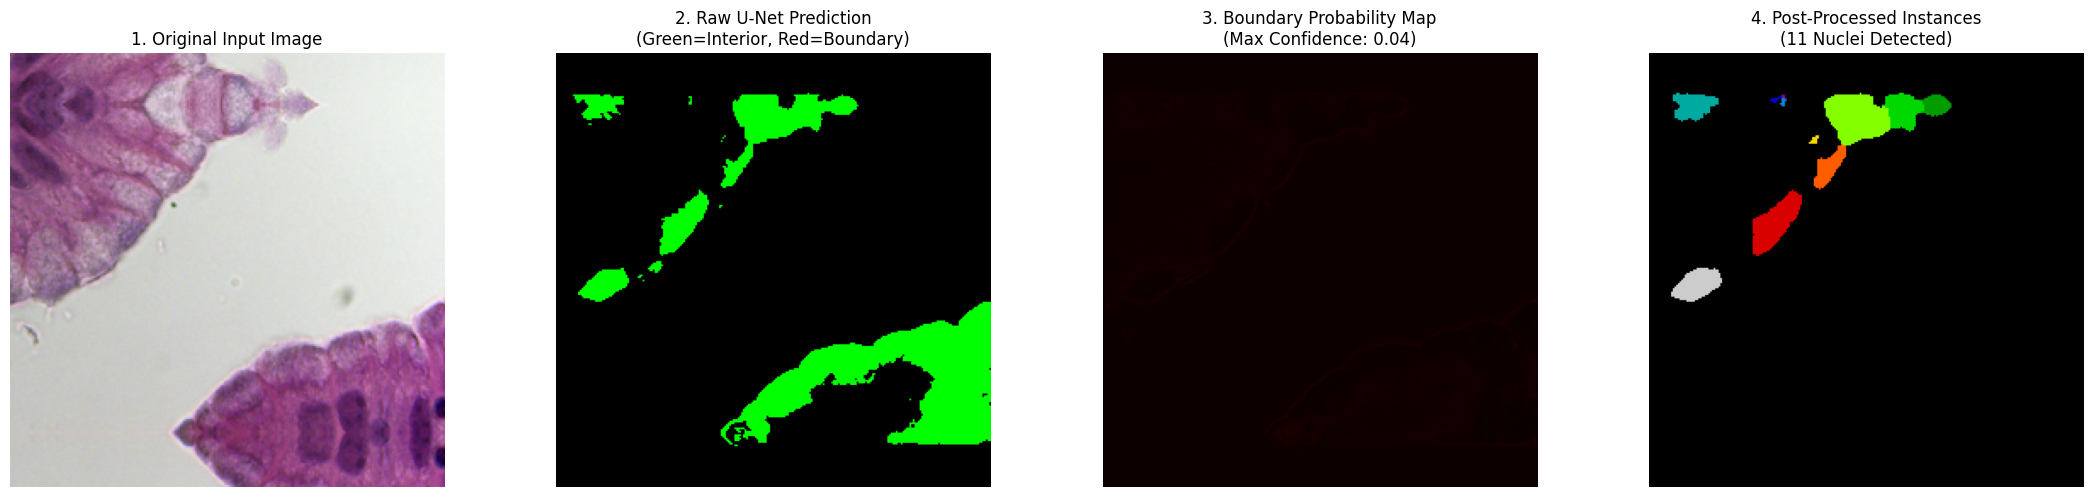

Processing: /kaggle/working/test_256/images/0999dab07b11bc85fb8464fc36c947fbd8b5d6ec49817361cb780659ca805eac.png ...
Post-processing isolated 118 individual nuclei instances!


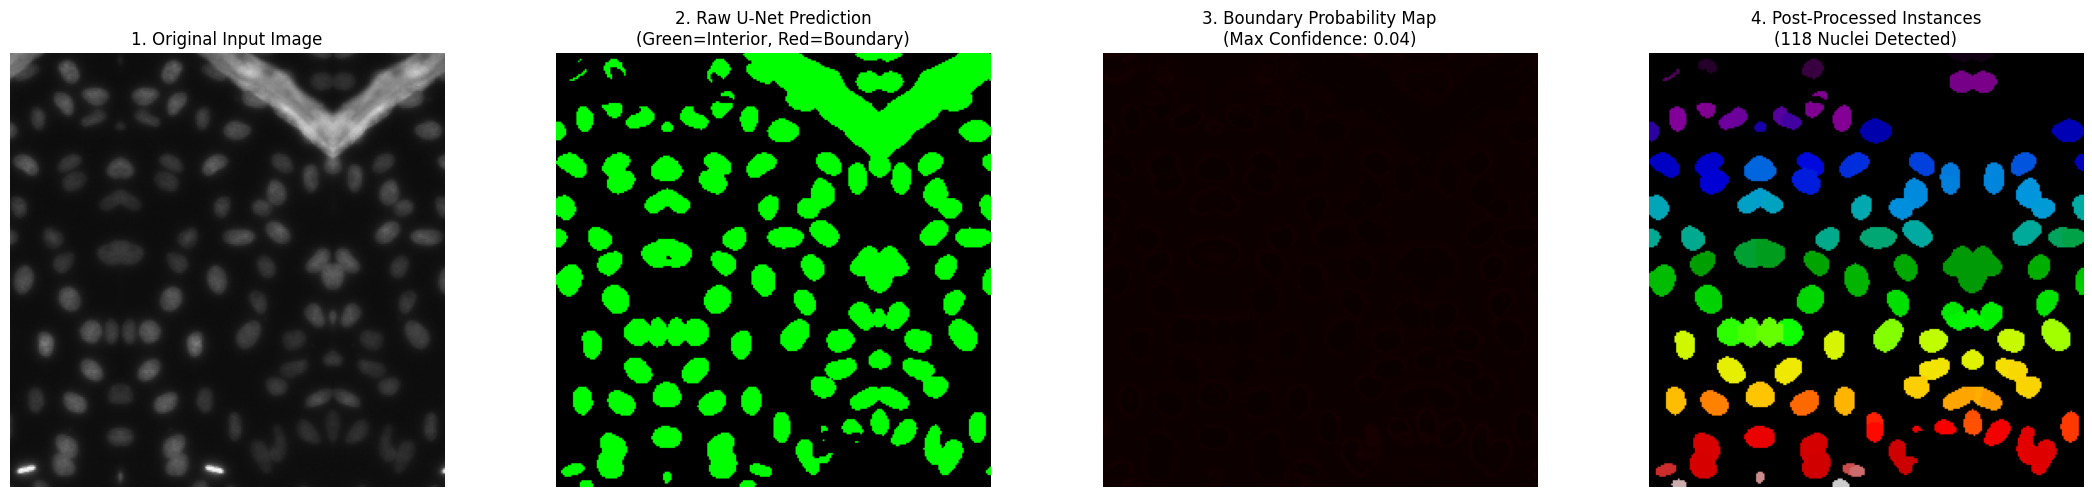

In [114]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
import torch
import torch.nn.functional as F

# ----------------------------------------------------------------------
# 1. Post-Processing Pipeline (Concavity + Watershed)
# ----------------------------------------------------------------------
def pinch_off_and_separate_concavity(
    binary_mask: np.ndarray,
    min_distance: int = 4,
    min_area: int = 15,
    max_area: int = 1500,
) -> tuple:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    eroded_mask = cv2.erode(binary_mask.astype(np.uint8), kernel, iterations=1)

    # Restore small nuclei lost during erosion
    missing_small_nuclei = (binary_mask.astype(bool)) & (~eroded_mask.astype(bool))
    labeled_missing, num_missing = ndimage.label(missing_small_nuclei)
    for m_idx in range(1, num_missing + 1):
        small_blob = labeled_missing == m_idx
        if 10 <= np.sum(small_blob) < 40:
            eroded_mask[small_blob] = 1

    initial_labels, num_initial = ndimage.label(eroded_mask)
    final_instances = np.zeros_like(binary_mask, dtype=np.int32)
    current_instance_id = 1

    for lab in range(1, num_initial + 1):
        component = (initial_labels == lab).astype(np.uint8)
        comp_area = np.sum(component)

        if comp_area < min_area or comp_area > max_area:
            continue

        contours, _ = cv2.findContours(
            component, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        if not contours:
            continue

        cnt = contours[0]
        hull = cv2.convexHull(cnt, returnPoints=False)

        has_concave_notch = False
        if len(hull) > 3:
            defects = cv2.convexityDefects(cnt, hull)
            if defects is not None:
                for i in range(defects.shape[0]):
                    s, e, f, d = defects[i, 0]
                    depth = d / 256.0
                    if depth > 1.8:
                        has_concave_notch = True
                        break

        distance = ndimage.distance_transform_edt(component)
        coords = peak_local_max(
            distance, min_distance=min_distance, labels=component > 0
        )

        if len(coords) > 1 or has_concave_notch:
            mask_peaks = np.zeros(distance.shape, dtype=bool)
            if len(coords) > 0:
                mask_peaks[tuple(coords.T)] = True
            markers, n_markers = ndimage.label(mask_peaks)

            if n_markers > 1:
                sub_instances = watershed(-distance, markers, mask=component > 0)
                for sub_id in range(1, n_markers + 1):
                    final_instances[sub_instances == sub_id] = current_instance_id
                    current_instance_id += 1
                continue

        final_instances[component > 0] = current_instance_id
        current_instance_id += 1

    final_instances_dilated = cv2.dilate(
        final_instances.astype(np.uint16), kernel, iterations=1
    )
    final_instances_dilated[binary_mask == 0] = 0

    return final_instances_dilated.astype(np.int32), current_instance_id - 1

# ----------------------------------------------------------------------
# 2. Prediction & Dual-Stage Output Generation
# ----------------------------------------------------------------------
def predict_raw_and_postprocess(
    net, raw_img, device, target_size=(256, 256), min_distance=4
):
    net.eval()
    w_orig, h_orig = raw_img.size

    # 1. Preprocess input & pass through U-Net
    img_ndarray = NucleiDataset.preprocess(
        raw_img, target_size=target_size, is_mask=False
    )
    img_tensor = (
        torch.from_numpy(img_ndarray).unsqueeze(0).to(device=device, dtype=torch.float32)
    )

    with torch.no_grad():
        logits = net(img_tensor)
        logits = F.interpolate(logits, (h_orig, w_orig), mode='bilinear')
        probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    prob_interior = probs[1]  # Class 1: Interior
    prob_boundary = probs[2]  # Class 2: Boundary

    # 2. RAW U-NET OUTPUT (Stage 1: Pure Neural Network Prediction)
    raw_argmax = np.argmax(probs, axis=0).astype(np.uint8)

    # 3. POST-PROCESSED OUTPUT (Stage 2: Concavity & Watershed Separation)
    # Binary mask created by penalizing boundary pixels
    foreground_prob = prob_interior - (1.5 * prob_boundary)
    binary_mask = (foreground_prob > 0.35).astype(np.uint8)

    if not binary_mask.any():
        labeled_instances = np.zeros_like(prob_interior, dtype=np.int32)
        num_nuclei = 0
    else:
        labeled_instances, num_nuclei = pinch_off_and_separate_concavity(
            binary_mask, min_distance=min_distance, min_area=15, max_area=1500
        )

    return raw_argmax, prob_boundary, labeled_instances, num_nuclei

# ----------------------------------------------------------------------
# 3. Inference & Visual Comparison Loop
# ----------------------------------------------------------------------
for img_path in INPUT_IMAGES:
    if not Path(img_path).exists():
        continue

    print(f'Processing: {img_path} ...')
    raw_img = Image.open(img_path).convert('RGB')

    raw_argmax, prob_boundary, instances, num_found = predict_raw_and_postprocess(
        net=model,
        raw_img=raw_img,
        device=device,
        target_size=(256, 256),
        min_distance=4,
    )

    print(f'Post-processing isolated {num_found} individual nuclei instances!')

    # Plot 4 panels: Input -> Raw Argmax -> Boundary Prob Heatmap -> Final Instances
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    # Panel 1: Original Image
    axes[0].imshow(raw_img)
    axes[0].set_title('1. Original Input Image')
    axes[0].axis('off')

    # Panel 2: Direct Model Output (Raw Argmax: Black=BG, Green=Interior, Red=Boundary)
    # Color mapping: 0 -> Black, 1 -> Green, 2 -> Red
    cmap_raw = plt.cm.colors.ListedColormap(['black', 'lime', 'red'])
    axes[1].imshow(raw_argmax, cmap=cmap_raw, vmin=0, vmax=2)
    axes[1].set_title('2. Raw U-Net Prediction\n(Green=Interior, Red=Boundary)')
    axes[1].axis('off')

    # Panel 3: Boundary Confidence Heatmap (Class 2 Probs)
    axes[2].imshow(prob_boundary, cmap='hot', vmin=0, vmax=1)
    axes[2].set_title(f'3. Boundary Probability Map\n(Max Confidence: {prob_boundary.max():.2f})')
    axes[2].axis('off')

    # Panel 4: Final Instance Segmentation (After Post-Processing)
    axes[3].imshow(instances, cmap='nipy_spectral', vmin=0)
    axes[3].set_title(f'4. Post-Processed Instances\n({num_found} Nuclei Detected)')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

Generating separate binary mask files for 65 test images...


Exporting Separate Masks:   0%|          | 0/17 [00:00<?, ?it/s]

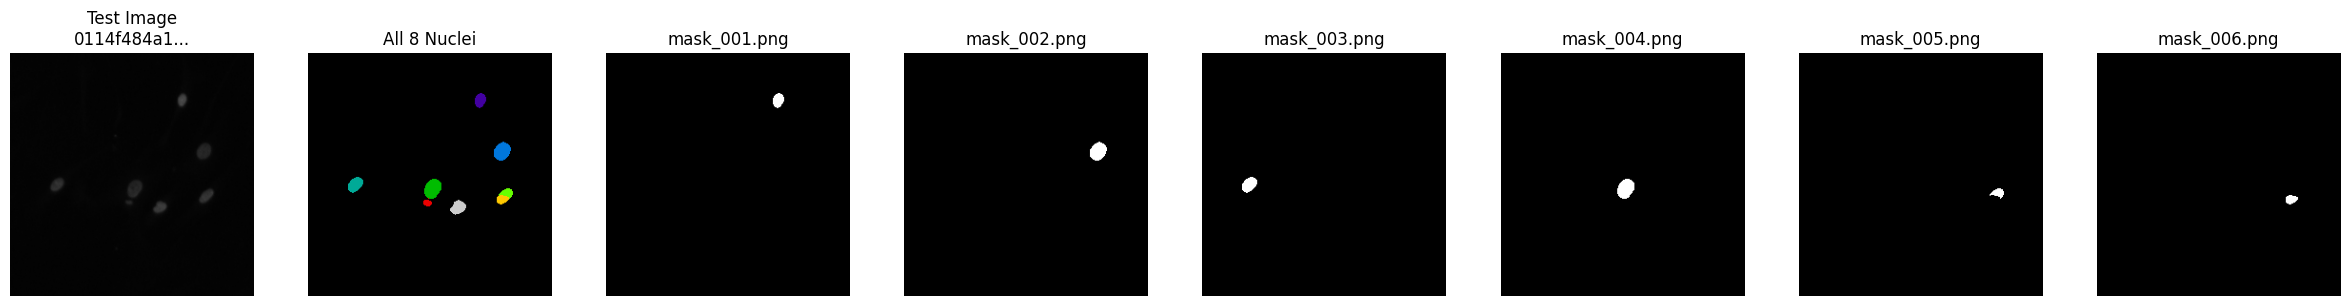

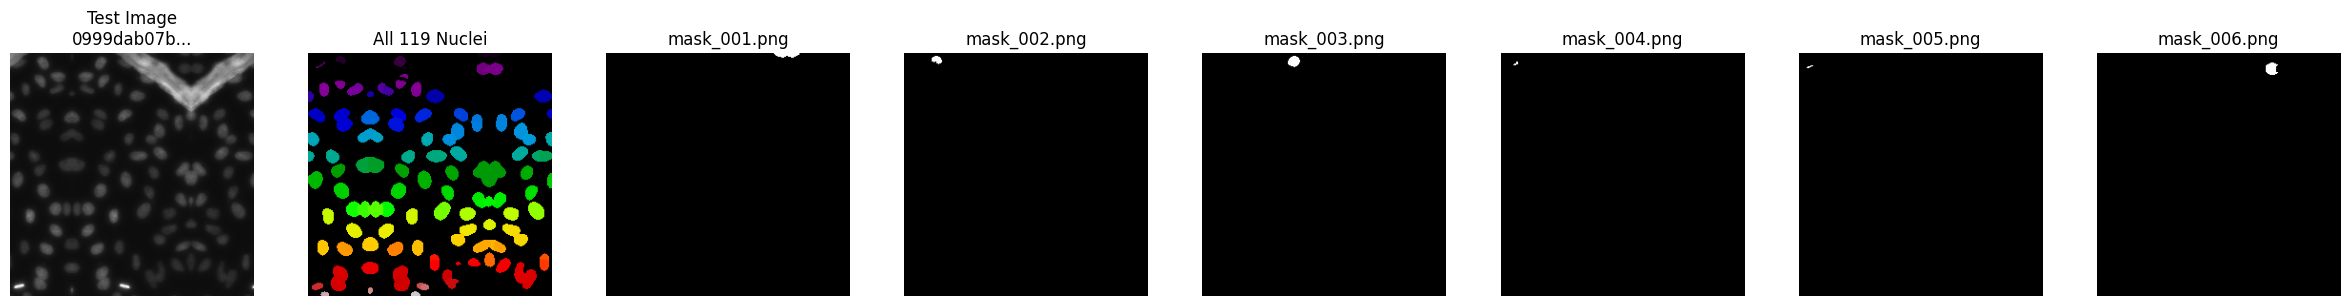

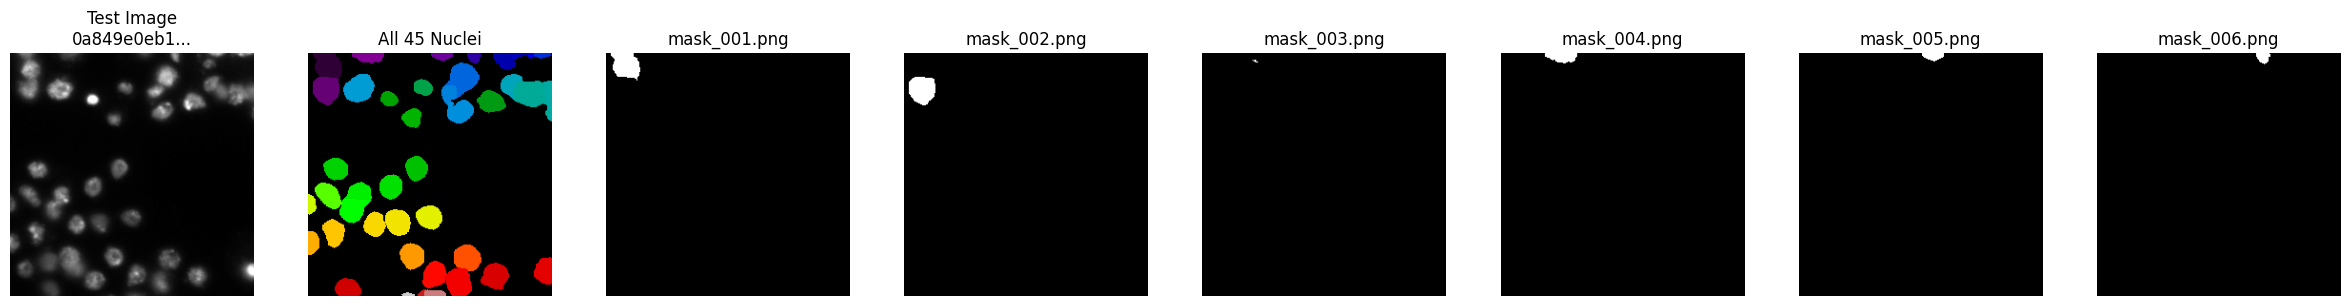

Exporting Separate Masks: 100%|██████████| 17/17 [00:18<00:00,  1.11s/it]


SUCCESS: Exported individual mask PNGs across 65 test images!
Total individual nucleus files saved: 4059
Root Folder: /kaggle/working/test_masks


In [125]:
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

# 1. Output Directory: ./test_masks/<image_id>/mask_001.png, mask_002.png...
OUTPUT_MASKS_DIR = Path('./test_masks')
OUTPUT_MASKS_DIR.mkdir(parents=True, exist_ok=True)


def export_and_display_individual_masks(
    model,
    test_loader,
    device,
    output_dir=OUTPUT_MASKS_DIR,
    amp=True,
    max_visualizations=5,  # Number of test samples to display inline
):
  """Extracts each detected nucleus into its own individual binary mask PNG (0 or 255) and visualizes the breakdown per image."""
  model.eval()
  total_masks_saved = 0

  print(
      f'Generating separate binary mask files for {len(test_loader.dataset)}'
      ' test images...'
  )

  with torch.no_grad():
    for batch_idx, batch in enumerate(
        tqdm(test_loader, desc='Exporting Separate Masks')
    ):
      images = batch['image'].to(device=device, dtype=torch.float32)
      image_ids = batch['image_id']

      with torch.amp.autocast(
          device_type=device.type if device.type != 'mps' else 'cpu',
          enabled=amp,
      ):
        logits = model(images)
        probs = F.softmax(logits, dim=1).cpu().numpy()

      for i in range(images.shape[0]):
        img_id = image_ids[i]
        prob_i = probs[i]

        prob_interior = prob_i[1]  # Class 1: Interior
        prob_boundary = prob_i[2]  # Class 2: Boundary

        # Post-Processing: Boundary penalty + Watershed separation
        foreground_prob = prob_interior - (1.5 * prob_boundary)
        binary_mask = (foreground_prob > 0.35).astype(np.uint8)

        if binary_mask.any():
          pred_instances, num_found = pinch_off_and_separate_concavity(
              binary_mask=binary_mask,
              min_distance=4,
              min_area=15,
              max_area=1500,
          )
        else:
          pred_instances = np.zeros_like(prob_interior, dtype=np.int32)
          num_found = 0

        # Create isolated folder for this test image: ./test_masks/<img_id>/
        image_mask_folder = output_dir / img_id
        image_mask_folder.mkdir(parents=True, exist_ok=True)

        individual_masks = []

        # SAVE SEPARATE MASK FOR EACH NUCLEUS
        if num_found > 0:
          for inst_id in range(1, num_found + 1):
            single_nucleus_binary = np.zeros_like(
                pred_instances, dtype=np.uint8
            )
            single_nucleus_binary[pred_instances == inst_id] = 255

            # Save as individual 8-bit PNG (0 or 255)
            mask_filename = image_mask_folder / f'mask_{inst_id:03d}.png'
            cv2.imwrite(str(mask_filename), single_nucleus_binary)

            individual_masks.append(single_nucleus_binary)
            total_masks_saved += 1
        else:
          # If no nuclei found, save a single blank mask
          blank_mask = np.zeros_like(prob_interior, dtype=np.uint8)
          cv2.imwrite(str(image_mask_folder / 'mask_000.png'), blank_mask)

        # --------------------------------------------------------------
        # INLINE VISUALIZATION: Display individual masks for inspection
        # --------------------------------------------------------------
        sample_num = batch_idx * test_loader.batch_size + i
        if sample_num < max_visualizations:
          display_count = min(num_found, 6)  # Show up to 6 separate masks
          fig, axes = plt.subplots(
              1,
              display_count + 2,
              figsize=(3 * (display_count + 2), 3),
          )

          # Input Image Tensor to HWC for plotting
          orig_img = images[i].cpu().numpy().transpose((1, 2, 0))
          axes[0].imshow(orig_img)
          axes[0].set_title(f'Test Image\n{img_id[:10]}...')
          axes[0].axis('off')

          # Combined Multi-Instance View
          axes[1].imshow(pred_instances, cmap='nipy_spectral', vmin=0)
          axes[1].set_title(f'All {num_found} Nuclei')
          axes[1].axis('off')

          # Plot first few individual mask PNGs
          for k in range(display_count):
            axes[k + 2].imshow(individual_masks[k], cmap='gray')
            axes[k + 2].set_title(f'mask_{k+1:03d}.png')
            axes[k + 2].axis('off')

          plt.tight_layout()
          plt.show()

  print('\n' + '=' * 60)
  print(
      f'SUCCESS: Exported individual mask PNGs across'
      f' {len(test_loader.dataset)} test images!'
  )
  print(f'Total individual nucleus files saved: {total_masks_saved}')
  print(f'Root Folder: {output_dir.resolve()}')
  print('=' * 60)


# ----------------------------------------------------------------------
# Execution Entry Point
# ----------------------------------------------------------------------
DIR_TEST_IMG = Path('./test_256/images')  # Path to your test images folder

test_dataset = NucleiDataset(DIR_TEST_IMG, mask_dir=None)
test_loader = DataLoader(
    test_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True
)

export_and_display_individual_masks(
    model=model,
    test_loader=test_loader,
    device=device,
    output_dir=OUTPUT_MASKS_DIR,
    amp=AMP,
    max_visualizations=3,  # Displays inline breakdown plots for first 3 test images
)

In [118]:
import numpy as np
import pandas as pd


def rle_decode(rle_str: str, shape: tuple = (256, 256)) -> np.ndarray:
  """Decodes a Kaggle Fortran-order RLE string into a 2D binary numpy mask."""
  if pd.isna(rle_str) or not str(rle_str).strip():
    return np.zeros(shape, dtype=np.uint8)

  s = list(map(int, rle_str.split()))
  starts, lengths = s[0::2], s[1::2]

  # 1-indexed to 0-indexed adjustment
  starts = np.asarray(starts) - 1
  ends = starts + np.asarray(lengths)

  # Construct 1D column-first array
  img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
  for lo, hi in zip(starts, ends):
    img[lo:hi] = 1

  # Reshape in Fortran order ('F') to restore original spatial dimensions (H, W)
  return img.reshape(shape, order='F')


def load_gt_instance_mask(
    df_train_labels: pd.DataFrame,
    image_id: str,
    target_shape: tuple = (256, 256),
) -> np.ndarray:
  """Combines multiple RLE rows for a single ImageId into a single 2D instance map (0=BG, 1..N=Nucleus IDs)."""
  rows = df_train_labels[df_train_labels['ImageId'] == image_id]
  gt_instances = np.zeros(target_shape, dtype=np.int32)

  for inst_idx, rle_str in enumerate(rows['EncodedPixels'], start=1):
    single_mask = rle_decode(rle_str, shape=target_shape)
    gt_instances[single_mask > 0] = inst_idx

  return gt_instances

In [128]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm


def rle_encode(mask: np.ndarray) -> str:
  """Encodes a binary 2D mask into Kaggle Fortran-order (column-first) RLE format.

  mask: 2D binary numpy array (True/255 for nucleus, False/0 for background)
  returns: Space-delimited string of 'start length' pairs (1-indexed,
  column-first)
  """
  # Transpose mask to switch from row-first to column-first ordering (Fortran order)
  pixels = mask.T.flatten()

  # Pad array at both ends to detect start and end transitions of runs reliably
  pixels = np.concatenate([[0], pixels, [0]])
  runs = np.where(pixels[1:] != pixels[:-1])[0] + 1

  # Calculate lengths of runs: end_idx - start_idx
  runs[1::2] -= runs[::2]

  return ' '.join(str(x) for x in runs)


def create_submission_from_mask_folders(
    test_masks_dir=Path('./test_masks'), output_csv_path='./submission.csv'
):
  """Iterates through each ImageId subfolder in test_masks_dir, encodes each individual binary mask PNG into RLE, and writes submission.csv."""
  test_masks_dir = Path(test_masks_dir)
  submission_rows = []

  # Find all ImageId subfolders
  image_folders = sorted([f for f in test_masks_dir.iterdir() if f.is_dir()])

  print(
      f'Generating Kaggle RLE CSV across {len(image_folders)} test image'
      ' folders...'
  )

  for img_folder in tqdm(image_folders, desc='Encoding RLE'):
    img_id = img_folder.name

    # Fetch all individual nucleus mask files for this ImageId
    mask_files = sorted(
        [
            p
            for p in img_folder.glob('*.png')
            if p.suffix.lower() in ['.png', '.jpg', '.tif']
        ]
    )

    has_valid_nucleus = False

    for mask_path in mask_files:
      # Read individual 8-bit binary mask (0 or 255)
      binary_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

      if binary_mask is None or not (binary_mask > 0).any():
        continue

      # Encode binary mask (threshold > 0 to get boolean array)
      rle_string = rle_encode(binary_mask > 0)

      if rle_string:
        submission_rows.append(
            {'ImageId': img_id, 'EncodedPixels': rle_string}
        )
        has_valid_nucleus = True

    # Fallback: Output empty prediction string if no nucleus was detected for the image
    if not has_valid_nucleus:
      submission_rows.append({'ImageId': img_id, 'EncodedPixels': ''})

  # Build DataFrame matching official submission schema
  df_sub = pd.DataFrame(submission_rows)
  df_sub.to_csv(output_csv_path, index=False)

  print('\n' + '=' * 60)
  print(f'SUCCESS: CSV successfully generated -> {output_csv_path}')
  print(f'Total Nucleus Instances Encoded: {len(df_sub)}')
  print(f'Total Unique Test Images: {df_sub["ImageId"].nunique()}')
  print('=' * 60)

  return df_sub


# ----------------------------------------------------------------------
# Execute CSV Generation & Inspect Output
# ----------------------------------------------------------------------
df_submission = create_submission_from_mask_folders(
    test_masks_dir=Path('./test_masks'), output_csv_path='./submission.csv'
)

# Display sample output format
print('\nFirst 10 rows of submission.csv:')
print(df_submission.head(10))

Generating Kaggle RLE CSV across 65 test image folders...


Encoding RLE: 100%|██████████| 65/65 [00:12<00:00,  5.15it/s]



SUCCESS: CSV successfully generated -> ./submission.csv
Total Nucleus Instances Encoded: 4058
Total Unique Test Images: 65

First 10 rows of submission.csv:
                                             ImageId  \
0  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
1  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
2  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
3  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
4  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
5  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
6  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
7  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
8  0999dab07b11bc85fb8464fc36c947fbd8b5d6ec498173...   
9  0999dab07b11bc85fb8464fc36c947fbd8b5d6ec498173...   

                                       EncodedPixels  
0  44849 7 45103 11 45358 13 45613 14 45869 15 46...  
1  50023 8 50278 10 50532 13 50787 15 51042 16 51...  
2  10891 7 11146 9 11400 12 11655 13 11910 15 121...  
3  31

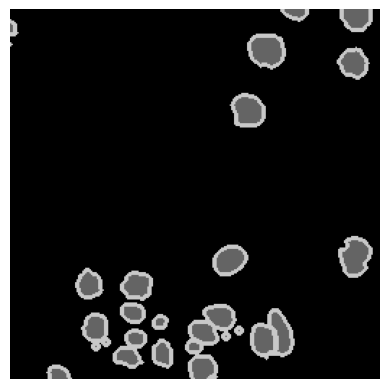

In [91]:
import cv2 as cv2
img = cv2.imread("/kaggle/working/dataset_3class/masks/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png")
plt.imshow(img)
plt.axis('off') # Optional: Hides the x and y axes ticks
plt.show()